In [1]:
import sys
import numpy as np
sys.path.append("../src/")
%load_ext autoreload
%autoreload 2

In [2]:
from generators.toy_problem_to_json import toy_problem_to_json # type: ignore[reportMissingImports]
from relaxers.quadratic_model_lin_approx import quadratic_model_lin_approx # type: ignore[reportMissingImports]
from relaxers.quadratic_lin_approx_no_surrogate import quadratic_lin_approx_no_surrogate # type: ignore[reportMissingImports]
from relaxers.quadratic_model_remove_quad import quadratic_model_remove_quad # type: ignore[reportMissingImports]
from testers.condition_number_lin_program import ( # type: ignore[reportMissingImports]
    condition_number,
    condition_number_no_bounds,
    condition_number_nes_basic
)
from relaxers.standard_form import standard_form # type: ignore[reportMissingImports]

np.set_printoptions(linewidth=np.inf)

In [4]:
# Number of copies of the network in the toy system
N=1

# Whether the production and flow variables have upper bounds
F_UPPER_BOUNDS=True

# Whether the demand constraint is an equality or inequality
DEMAND_INEQUALITY=False

# Capacity / demand parameters
GAMMA=1.0
# GAMMA=3.0
LAMBD=1.0
EPS=0.1
DELTA=0.1

# Lower bounds and upper bound on pressure
LX=LP=LF=0.0
UP=5.0

# The number of linear constraints to use per quadratic constraint
LIN_CONSTRAINTS = 5

# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = False

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

# Whether to divide by lambda in an inner approximation
REMOVE_DIVISION = False

There are 9 variables, 2 equality constraints, and 0 non-bound inequality constraints
Removed 5 unused variables
A =
[[ 1.  1.  0. -1.]
 [ 0.  0. -1. -1.]]
cond(A) = 1.6180339887498951
A' =
[]
[[ 3.  1.  0. -1.]
 [ 1.  3.  0. -1.]
 [ 0.  0.  3.  1.]
 [-1. -1.  1.  4.]]
Sparsity of NES: 0.25
AxesImage(shape=(4, 4))


np.float64(2.809016994374947)

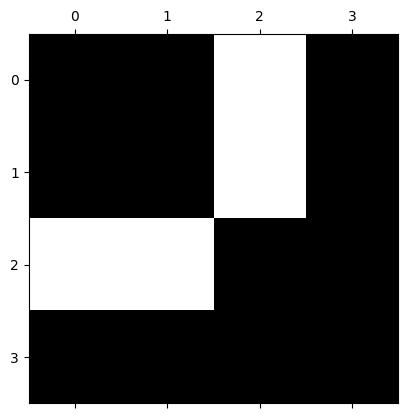

In [5]:
toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
quadratic_model_remove_quad()
condition_number_nes_basic(bounds=2, verbose=True)

There are 9 variables, 2 equality constraints, and 20 non-bound inequality constraints
Removed 0 unused variables
A =
[[ 0.  0.  0.  0.  0.  1.  1.  0. -1.]
 [ 0.  0.  0.  0.  0.  0.  0. -1. -1.]]
cond(A) = 1.6180339887498947
A' =
[[ 1.    0.    0.   -1.    0.   -0.2   0.    0.    0.  ]
 [ 1.    0.    0.   -1.    0.   -0.6   0.    0.    0.  ]
 [ 1.    0.    0.   -1.    0.   -1.    0.    0.    0.  ]
 [ 1.    0.    0.   -1.    0.   -1.4   0.    0.    0.  ]
 [ 1.    0.    0.   -1.    0.   -1.8   0.    0.    0.  ]
 [ 0.    1.    0.   -1.    0.    0.   -0.22  0.    0.  ]
 [ 0.    1.    0.   -1.    0.    0.   -0.66  0.    0.  ]
 [ 0.    1.    0.   -1.    0.    0.   -1.1   0.    0.  ]
 [ 0.    1.    0.   -1.    0.    0.   -1.54  0.    0.  ]
 [ 0.    1.    0.   -1.    0.    0.   -1.98  0.    0.  ]
 [ 0.    0.    1.    0.   -1.    0.    0.   -0.22  0.  ]
 [ 0.    0.    1.    0.   -1.    0.    0.   -0.66  0.  ]
 [ 0.    0.    1.    0.   -1.    0.    0.   -1.1   0.  ]
 [ 0.    0.    1.    0.   -1

np.float64(1.2821074022844938e+17)

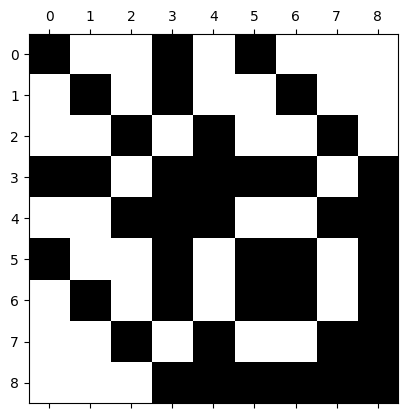

In [ ]:
toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
# quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
condition_number_nes_basic(bounds=2, verbose=True)

There are 28 variables, 12 equality constraints, and 88 non-bound inequality constraints
Removed 0 unused variables
A =
[[ 0.          1.         -1.          0.          0.          1.          0.          0.         -1.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
 [ 0.         -1.          0.          1.          1.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.         -1.         -1.          0.          0.          0.          1.          0.          0.          0.          0.          0.          0.          0.     

np.float64(923022.0807610202)

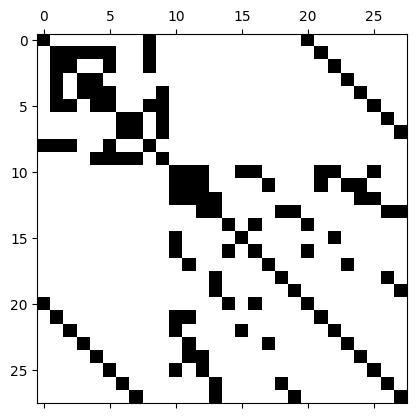

In [7]:
quadratic_model_lin_approx(10, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                f_name="model11_quad_reform.json")
# quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
#                                 SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
#                                 f_name="model11_quad.json")
# quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, True, f_name="model11_quad_reform.json")
# quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, True, f_name="model11_quad.json")
condition_number_nes_basic(bounds=0, verbose=True)

There are 117 variables, 101 equality constraints, and 0 non-bound inequality constraints
Removed 0 unused variables
A =
[[ 0.  0.  1. ...  0.  0.  0.]
 [ 0.  0. -1. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  1.  0.  0.]
 [ 0.  0.  0. ...  0.  1.  0.]
 [ 0.  0.  0. ...  0.  0.  1.]]
cond(A) = 18857.13882604042
A' =
[]
[[ 3.00000000e+00 -1.00000000e+00  0.00000000e+00 ...  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.00000000e+00  9.01035557e+03  0.00000000e+00 ...  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  9.01035557e+03 ...  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  3.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00  3.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00  0.00000000e+00  3.00000000e+00]]
Sparsity of NES: 0.95711885

np.float64(4510.588098610856)

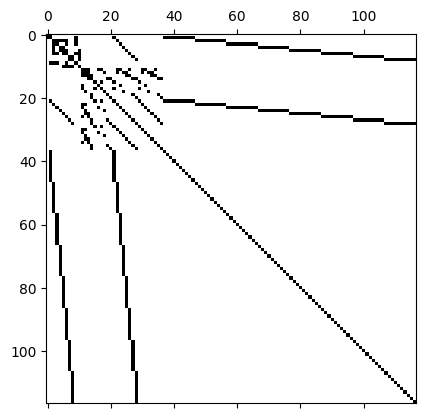

In [40]:
quadratic_model_lin_approx(10, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                f_name="model11_quad_reform.json")
standard_form()
condition_number_nes_basic(bounds=2, verbose=True)